# Agricultural Loan NPAs in India — Data-Driven Exploration

**Motivating observation:** Agri loan default rate in Gujarat is reported to have risen to ~11% recently.

**Research question:** Is there a relationship between Agri credit / banking-sector NPAs in India and the broader
economy — particularly during recession/slowdown years (2000, 2008, 2020)?

---

## ⚠️ Read this before trusting any conclusion below

This notebook is built strictly around the two sheets you supplied (`Agri_data.xlsx`). Before running the
analysis, it is important to be explicit about what the data can and cannot support:

1. **No Gujarat-specific data.** Everything in the workbook is **All-India**. The notebook can *contextualize*
   the Gujarat 11% figure against the national trend, but it **cannot confirm, explain, or attribute** the
   Gujarat number — that needs state-level data (e.g., SLBC Gujarat reports, NABARD state reports) which is not
   in this file.
2. **Sector ambiguity in Sheet2.** The columns are labelled `Credit all India`, `GNPA/Gross Advances Ratio`, and
   `GNPA`. Nothing in the header confirms these are **Agriculture-sector-specific** NPAs as opposed to
   **whole-banking-system (all-sector)** NPAs. The notebook treats them as given and flags this ambiguity
   wherever the ratio is used — you should verify the original source (RBI Financial Stability Report /
   Handbook of Statistics) before making a sector-specific claim in your final writeup.
3. **Unequal time coverage** (see the coverage check in the next cell):
   - GDP growth: 1970–2025 (full).
   - Agri Credit Outstanding / Limit: only from 1998.
   - Quarterly "Credit all India": from Q4 1998.
   - GNPA/Gross Advances Ratio: only from **Q1 2002** — i.e., **the Dot-Com-era slowdown (2000) has NO NPA data
     at all.** Any conclusion about NPA behaviour in 2000 is therefore impossible with this dataset; you can
     only comment on GDP/credit growth for that year.
   - GNPA absolute amount: only from **Q1 2015** onward.
4. **Only 3 recession-like events are even partially observable**, and with very different data completeness:
   - **2000 (dot-com slowdown):** GDP + credit growth only. No NPA data → conclusion limited to "credit growth
     slowed/didn't slow."
   - **2008 (GFC):** GDP, credit growth, AND GNPA ratio available → full comparison possible.
   - **2020 (COVID):** GDP, credit growth, GNPA ratio, AND GNPA absolute amount available → richest comparison.
5. **Correlation ≠ causation**, and with only ~24 annual overlapping data points (2002–2025) for GDP vs GNPA,
   statistical power is low — treat correlation coefficients as *indicative*, not conclusive.
6. **Units:** `Credit all India`, `GNPA`, `Credit Outstanding Agri`, and `Credit Limit Agri` are supplied in
   **₹ Million**. The notebook converts these to **₹ Lakh Crore** (1 Lakh Crore = 10,000 Crore = 1,000,000
   Million) for chart readability — tables retain the original ₹ Million figures unless noted.

**Bottom line on what you *can* credibly claim from this data:** whether All-India agri-linked credit growth and
the (possibly all-sector) GNPA ratio moved in a plausible direction relative to GDP growth during 2008 and 2020,
and whether that relationship is broadly consistent with the "recessions raise loan stress" hypothesis — nothing
stronger than that, and nothing at all about Gujarat specifically or about the 2000 episode's NPA behaviour.


In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Dark theme template for all plots
import plotly.io as pio
pio.templates.default = "plotly_dark"

DATA_PATH = "Agri_data.xlsx"   # place Agri_data.xlsx in the same folder as this notebook


## 1. Load & clean the two sheets

In [2]:
# Sheet1: Annual GDP growth + Agri credit outstanding/limit
df_annual = pd.read_excel(DATA_PATH, sheet_name="Sheet1")
df_annual.columns = [c.strip() for c in df_annual.columns]
df_annual = df_annual.rename(columns={
    "YEAR": "date",
    "GDP Growth": "gdp_growth",
    "Credit Outstanding Agri": "agri_credit_outstanding",
    "Credit Limit Agri": "agri_credit_limit"
})
df_annual["year"] = pd.to_datetime(df_annual["date"]).dt.year
df_annual = df_annual.drop(columns=["date"]).sort_values("year").reset_index(drop=True)

# Source values are in ₹ Million. Add ₹ Lakh Crore columns for readability
# (1 ₹ Lakh Crore = ₹ 1,000,000 Million = ₹ 10,000 Crore).
for col in ["agri_credit_outstanding", "agri_credit_limit"]:
    df_annual[col + "_lakh_cr"] = df_annual[col] / 1e6

# Sheet2: Quarterly credit (all-India) + GNPA ratio + GNPA amount
df_q = pd.read_excel(DATA_PATH, sheet_name="Sheet2")
df_q.columns = [c.strip() for c in df_q.columns]
df_q = df_q.rename(columns={
    "Quater": "date",
    "Credit all India": "credit_all_india",
    "GNPA/Gross Advances Ratio": "gnpa_ratio",
    "GNPA": "gnpa_amount"
})
df_q["date"] = pd.to_datetime(df_q["date"])
df_q["year"] = df_q["date"].dt.year
df_q["quarter"] = df_q["date"].dt.quarter
df_q = df_q.sort_values("date").reset_index(drop=True)

# Source values are in ₹ Million. Add ₹ Lakh Crore columns for readability.
for col in ["credit_all_india", "gnpa_amount"]:
    df_q[col + "_lakh_cr"] = df_q[col] / 1e6

print("Annual sheet shape:", df_annual.shape)
print("Quarterly sheet shape:", df_q.shape)
df_annual.tail()


Annual sheet shape: (56, 6)
Quarterly sheet shape: (110, 8)


,gdp_growth,agri_credit_outstanding,agri_credit_limit,year,agri_credit_outstanding_lakh_cr,agri_credit_limit_lakh_cr
51,9.41,"15,181,121.24","18,276,913.32",2021,15.18,18.28
52,6.97,"17,033,147.21","20,412,694.72",2022,17.03,20.41
53,8.83,"19,074,435.24","22,908,740.86",2023,19.07,22.91
54,7.24,"22,396,047.51","27,020,383.64",2024,22.40,27.02
55,7.53,"24,202,227.29","30,535,096.51",2025,24.20,30.54


In [3]:
df_q.tail()

,date,credit_all_india,gnpa_ratio,gnpa_amount,year,quarter,credit_all_india_lakh_cr,gnpa_amount_lakh_cr
105,2025-03-01,"181,134,476.12",2.31,"1,448,678.68",2025,1,181.13,1.45
106,2025-06-01,"182,204,843.13",2.32,"1,494,377.53",2025,2,182.20,1.49
107,2025-09-01,"188,750,707.67",2.15,"1,478,371.41",2025,3,188.75,1.48
108,2025-12-01,"197,330,350.22",1.99,"1,454,018.38",2025,4,197.33,1.45
109,2026-03-01,"207,423,058.26",NaN,NaN,2026,1,207.42,NaN


## 2. Data coverage check — what years actually have usable numbers?

In [4]:
def coverage(df, date_col_is_year=True):
    rows = []
    for col in df.columns:
        if col in ("year", "quarter"):
            continue
        s = df[[col, "year"]].dropna(subset=[col])
        if s.empty:
            rows.append((col, None, None, 0))
        else:
            rows.append((col, s["year"].min(), s["year"].max(), s["year"].nunique()))
    return pd.DataFrame(rows, columns=["variable", "first_year", "last_year", "n_years_with_data"])

cov_annual = coverage(df_annual)
cov_q = coverage(df_q)
coverage_summary = pd.concat([cov_annual, cov_q], ignore_index=True)
coverage_summary


,variable,first_year,last_year,n_years_with_data
0,gdp_growth,1970,2025,56
1,agri_credit_outstanding,1998,2025,28
2,agri_credit_limit,1998,2025,28
3,agri_credit_outstanding_lakh_cr,1998,2025,28
4,agri_credit_limit_lakh_cr,1998,2025,28
5,date,1998,2026,29
6,credit_all_india,1998,2026,29
7,gnpa_ratio,2002,2025,24
8,gnpa_amount,2015,2025,11
9,credit_all_india_lakh_cr,1998,2026,29


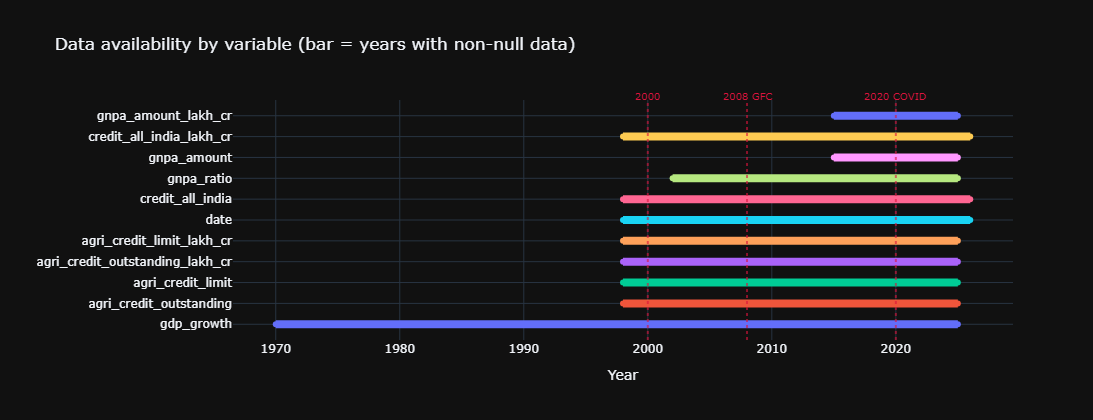

In [5]:
fig = go.Figure()
for i, row in coverage_summary.dropna(subset=["first_year"]).iterrows():
    fig.add_trace(go.Scatter(
        x=[row["first_year"], row["last_year"]],
        y=[row["variable"], row["variable"]],
        mode="lines+markers",
        line=dict(width=8),
        name=row["variable"],
        showlegend=False
    ))

# mark recession years
for yr, label in [(2000, "2000"), (2008, "2008 GFC"), (2020, "2020 COVID")]:
    fig.add_vline(x=yr, line_dash="dot", line_color="crimson", opacity=0.6)
    fig.add_annotation(x=yr, y=1.05, yref="paper", text=label, showarrow=False, font=dict(size=10, color="crimson"))

fig.update_layout(title="Data availability by variable (bar = years with non-null data)",
                   xaxis_title="Year", yaxis_title="", height=420)
fig.show()


## 3. GDP growth — the full picture (1970–2025)

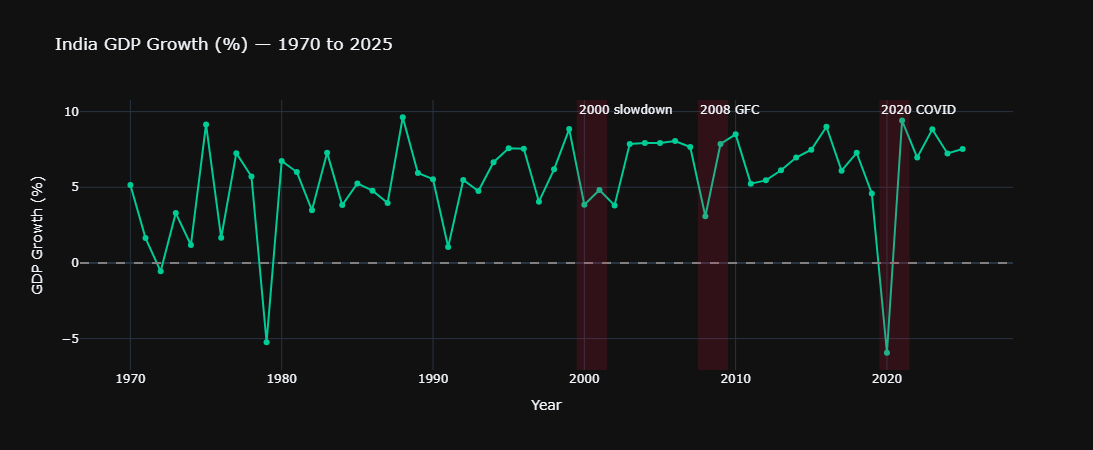

In [6]:
recession_windows = [
    (1999.5, 2001.5, "2000 slowdown"),
    (2007.5, 2009.5, "2008 GFC"),
    (2019.5, 2021.5, "2020 COVID"),
]

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_annual["year"], y=df_annual["gdp_growth"],
                          mode="lines+markers", name="GDP Growth (%)",
                          line=dict(color="#00CC96", width=2)))
fig.add_hline(y=0, line_color="gray", line_dash="dash")

for x0, x1, label in recession_windows:
    fig.add_vrect(x0=x0, x1=x1, fillcolor="crimson", opacity=0.15, line_width=0,
                  annotation_text=label, annotation_position="top left")

fig.update_layout(title="India GDP Growth (%) — 1970 to 2025", xaxis_title="Year",
                   yaxis_title="GDP Growth (%)", height=450)
fig.show()


## 4. Agri credit — outstanding vs sanctioned limit (1998–2025)

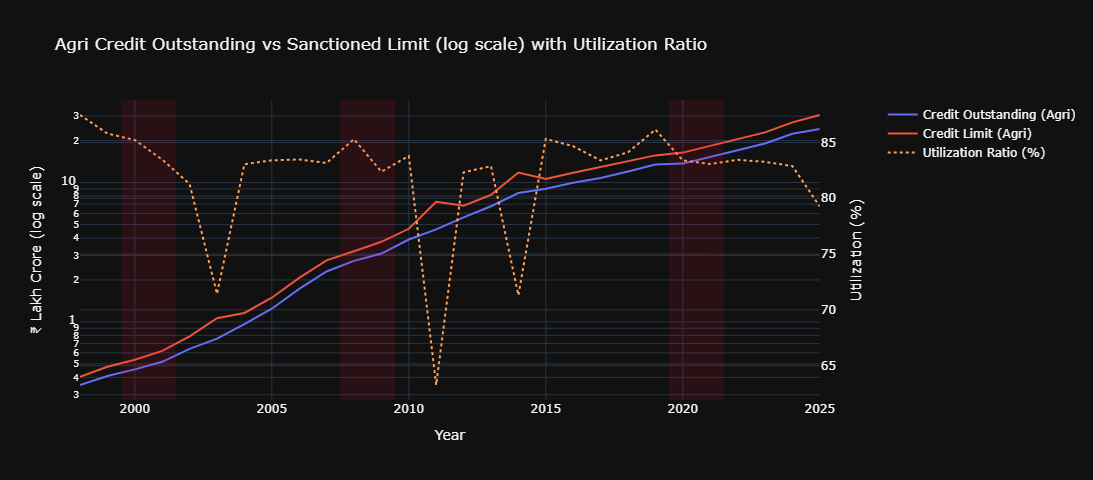

In [7]:
agri = df_annual.dropna(subset=["agri_credit_outstanding", "agri_credit_limit"]).copy()
agri["utilization_ratio"] = agri["agri_credit_outstanding"] / agri["agri_credit_limit"]
agri["credit_outstanding_yoy"] = agri["agri_credit_outstanding"].pct_change() * 100

# Values are supplied in ₹ Million; plot in ₹ Lakh Crore for readability (1 Lakh Cr = 1,000,000 Million)
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=agri["year"], y=agri["agri_credit_outstanding_lakh_cr"],
                          name="Credit Outstanding (Agri)", line=dict(color="#636EFA")), secondary_y=False)
fig.add_trace(go.Scatter(x=agri["year"], y=agri["agri_credit_limit_lakh_cr"],
                          name="Credit Limit (Agri)", line=dict(color="#EF553B")), secondary_y=False)
fig.add_trace(go.Scatter(x=agri["year"], y=agri["utilization_ratio"]*100,
                          name="Utilization Ratio (%)", line=dict(color="#FFA15A", dash="dot")), secondary_y=True)

for x0, x1, label in recession_windows:
    fig.add_vrect(x0=x0, x1=x1, fillcolor="crimson", opacity=0.12, line_width=0)

fig.update_yaxes(title_text="₹ Lakh Crore (log scale)", secondary_y=False, type="log")
fig.update_yaxes(title_text="Utilization (%)", secondary_y=True)
fig.update_layout(title="Agri Credit Outstanding vs Sanctioned Limit (log scale) with Utilization Ratio",
                   xaxis_title="Year", height=480)
fig.show()


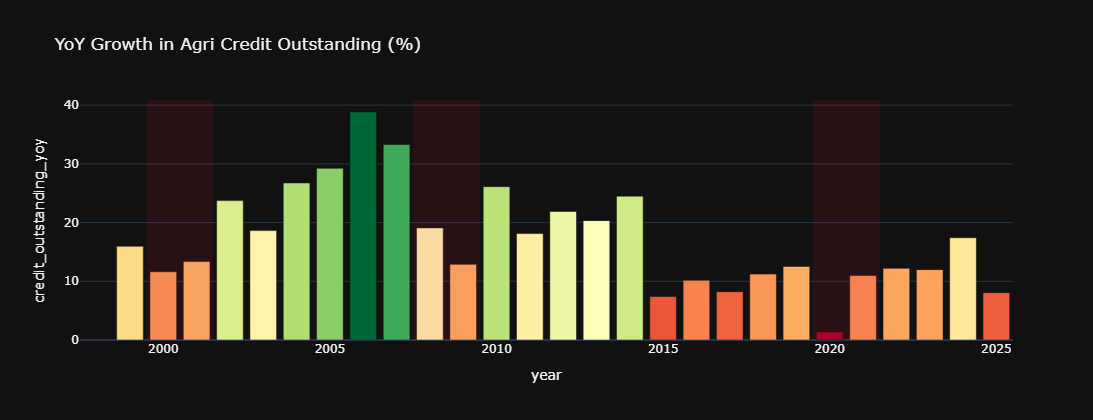

In [8]:
fig = px.bar(agri, x="year", y="credit_outstanding_yoy",
             title="YoY Growth in Agri Credit Outstanding (%)",
             color="credit_outstanding_yoy", color_continuous_scale="RdYlGn")
for x0, x1, label in recession_windows:
    fig.add_vrect(x0=x0, x1=x1, fillcolor="crimson", opacity=0.12, line_width=0)
fig.update_layout(height=420, coloraxis_showscale=False)
fig.show()


## 5. Banking-sector GNPA ratio — quarterly (2002–2026)

Remember: sector-specificity of this ratio (Agri-only vs whole book) is **not confirmed** by the column header — treat as All-India banking-system NPA unless you verify otherwise.

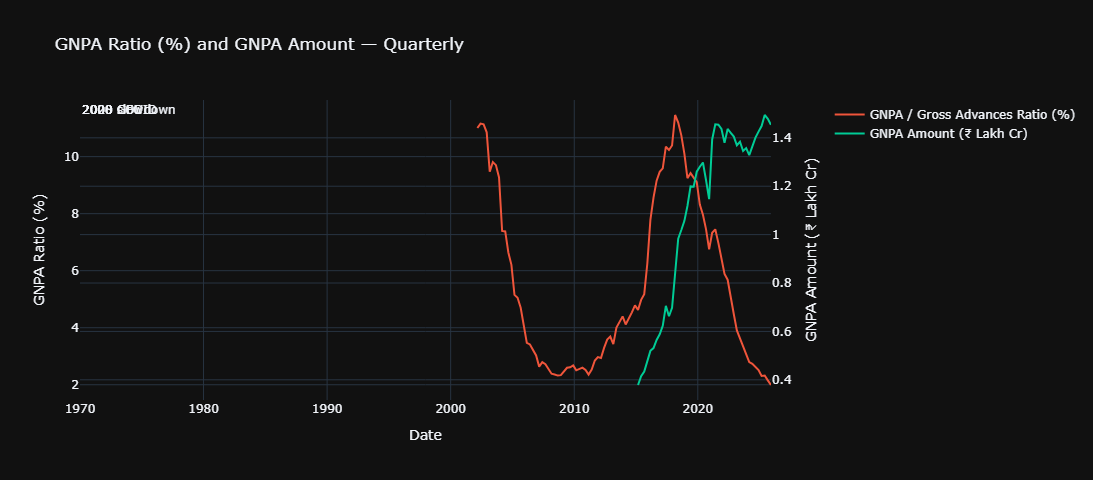

In [9]:
gnpa_q = df_q.dropna(subset=["gnpa_ratio"]).copy()

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=gnpa_q["date"], y=gnpa_q["gnpa_ratio"],
                          name="GNPA / Gross Advances Ratio (%)", line=dict(color="#EF553B", width=2)))
gnpa_amt = df_q.dropna(subset=["gnpa_amount"])
fig.add_trace(go.Scatter(x=gnpa_amt["date"], y=gnpa_amt["gnpa_amount_lakh_cr"],
                          name="GNPA Amount (₹ Lakh Cr)", line=dict(color="#00CC96", width=2), yaxis="y2"))

for x0, x1, label in recession_windows:
    fig.add_vrect(x0=x0, x1=x1, fillcolor="crimson", opacity=0.12, line_width=0,
                  annotation_text=label, annotation_position="top left")

fig.update_layout(
    title="GNPA Ratio (%) and GNPA Amount — Quarterly",
    xaxis_title="Date",
    yaxis=dict(title="GNPA Ratio (%)"),
    yaxis2=dict(title="GNPA Amount (₹ Lakh Cr)", overlaying="y", side="right"),
    height=480
)
fig.show()


## 6. Bringing GDP growth and GNPA ratio together (annual view, 2002–2025 overlap only)

In [10]:
annual_gnpa = df_q.dropna(subset=["gnpa_ratio"]).groupby("year")["gnpa_ratio"].mean().reset_index()
annual_credit = df_q.groupby("year")["credit_all_india"].last().reset_index()
annual_credit["credit_yoy"] = annual_credit["credit_all_india"].pct_change() * 100

master = df_annual.merge(annual_gnpa, on="year", how="left").merge(annual_credit, on="year", how="left")
master = master.merge(agri[["year", "utilization_ratio", "credit_outstanding_yoy"]], on="year", how="left")

overlap = master.dropna(subset=["gdp_growth", "gnpa_ratio"]).copy()
print(f"Years with both GDP growth and GNPA ratio available: {overlap['year'].min()}–{overlap['year'].max()} "
      f"({len(overlap)} data points)")
overlap[["year", "gdp_growth", "gnpa_ratio", "credit_yoy"]]


Years with both GDP growth and GNPA ratio available: 2002–2025 (24 data points)


,year,gdp_growth,gnpa_ratio,credit_yoy
32,2002,3.80,11.04,19.27
33,2003,7.86,9.56,15.24
34,2004,7.92,6.90,30.60
35,2005,7.92,4.75,30.11
36,2006,8.06,3.28,30.41
37,2007,7.66,2.68,21.25
38,2008,3.09,2.35,23.28
39,2009,7.86,2.58,12.20
40,2010,8.50,2.54,26.63
41,2011,5.24,2.68,15.98


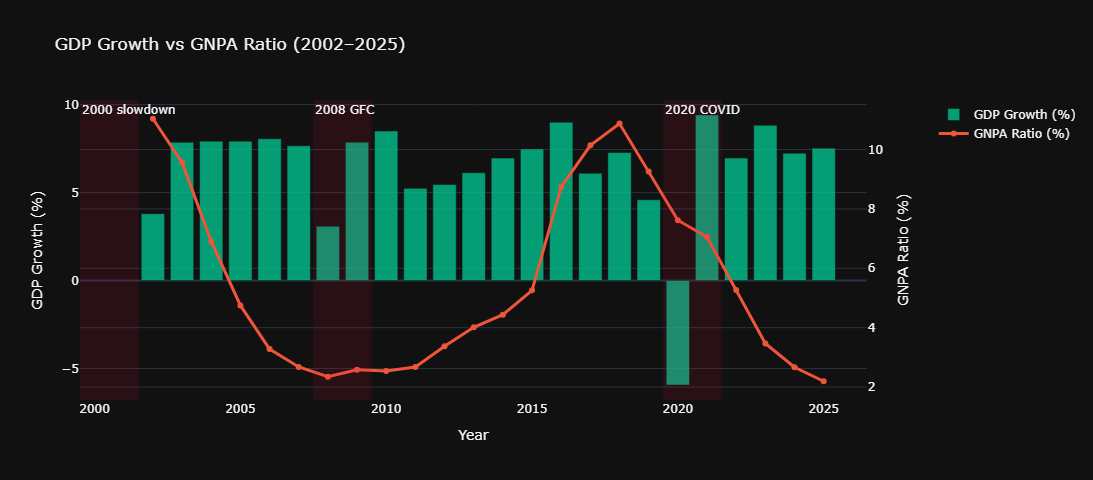

In [11]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Bar(x=overlap["year"], y=overlap["gdp_growth"], name="GDP Growth (%)",
                      marker_color="#00CC96", opacity=0.75), secondary_y=False)
fig.add_trace(go.Scatter(x=overlap["year"], y=overlap["gnpa_ratio"], name="GNPA Ratio (%)",
                          line=dict(color="#EF553B", width=3), mode="lines+markers"), secondary_y=True)

for x0, x1, label in recession_windows:
    fig.add_vrect(x0=x0, x1=x1, fillcolor="crimson", opacity=0.12, line_width=0,
                  annotation_text=label, annotation_position="top left")

fig.update_yaxes(title_text="GDP Growth (%)", secondary_y=False)
fig.update_yaxes(title_text="GNPA Ratio (%)", secondary_y=True)
fig.update_layout(title="GDP Growth vs GNPA Ratio (2002–2025)", xaxis_title="Year", height=480)
fig.show()


## 7. Correlation analysis

Note the small sample (n≈24 annual points) — interpret coefficients as indicative, not statistically decisive.

In [12]:
# Contemporaneous correlation
r_pearson, p_pearson = stats.pearsonr(overlap["gdp_growth"], overlap["gnpa_ratio"])
r_spearman, p_spearman = stats.spearmanr(overlap["gdp_growth"], overlap["gnpa_ratio"])

# Lagged: GNPA often shows up 1 year AFTER the growth shock (recognition lag)
overlap_sorted = overlap.sort_values("year").reset_index(drop=True)
overlap_sorted["gnpa_ratio_next_year"] = overlap_sorted["gnpa_ratio"].shift(-1)
lagged = overlap_sorted.dropna(subset=["gdp_growth", "gnpa_ratio_next_year"])
r_lag, p_lag = stats.pearsonr(lagged["gdp_growth"], lagged["gnpa_ratio_next_year"])

print(f"Contemporaneous Pearson r  (GDP growth vs GNPA ratio, same year):  r={r_pearson:.3f}, p={p_pearson:.3f}")
print(f"Contemporaneous Spearman rho:                                     rho={r_spearman:.3f}, p={p_spearman:.3f}")
print(f"Lagged Pearson r (GDP growth vs NEXT YEAR's GNPA ratio):          r={r_lag:.3f}, p={p_lag:.3f}")
print(f"\nn (contemporaneous) = {len(overlap)}, n (lagged) = {len(lagged)}")


Contemporaneous Pearson r  (GDP growth vs GNPA ratio, same year):  r=-0.175, p=0.414
Contemporaneous Spearman rho:                                     rho=-0.124, p=0.563
Lagged Pearson r (GDP growth vs NEXT YEAR's GNPA ratio):          r=-0.179, p=0.413

n (contemporaneous) = 24, n (lagged) = 23


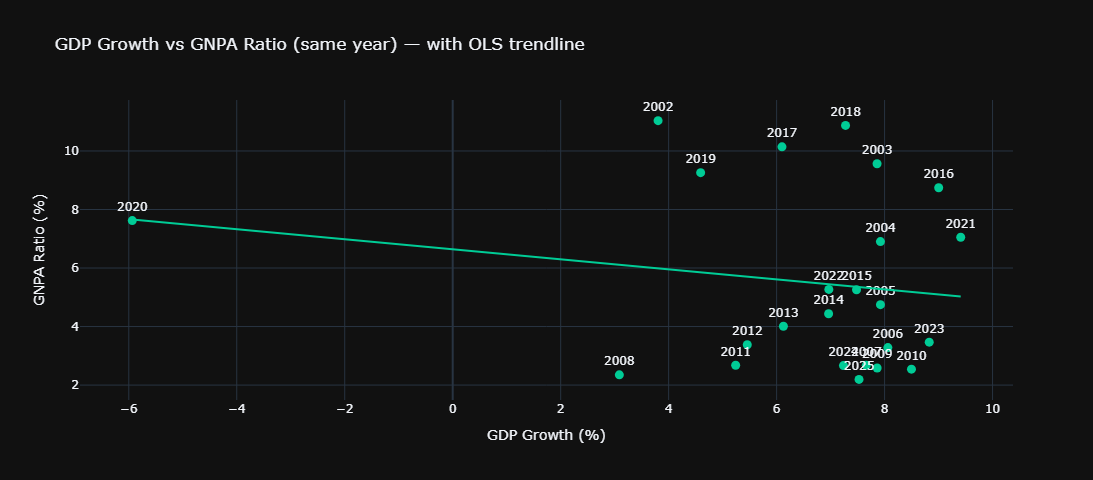

In [13]:
fig = px.scatter(overlap, x="gdp_growth", y="gnpa_ratio", text="year", trendline="ols",
                  title="GDP Growth vs GNPA Ratio (same year) — with OLS trendline",
                  labels={"gdp_growth": "GDP Growth (%)", "gnpa_ratio": "GNPA Ratio (%)"})
fig.update_traces(textposition="top center", marker=dict(size=9, color="#00CC96"))
fig.update_layout(height=480)
fig.show()


## 8. Recession-window comparisons

- **2000:** NPA data unavailable — GDP & credit growth only.
- **2008 GFC** and **2020 COVID:** full comparison (GDP, credit growth, GNPA ratio).

In [14]:
def window_table(center_year, span=2):
    yrs = list(range(center_year - span, center_year + span + 1))
    sub = master[master["year"].isin(yrs)][
        ["year", "gdp_growth", "credit_outstanding_yoy", "credit_yoy", "gnpa_ratio"]
    ].reset_index(drop=True)
    return sub

print("=== Window around 2000 (no GNPA data available) ===")
display(window_table(2000))

print("\n=== Window around 2008 GFC ===")
display(window_table(2008))

print("\n=== Window around 2020 COVID ===")
display(window_table(2020))


=== Window around 2000 (no GNPA data available) ===


,year,gdp_growth,credit_outstanding_yoy,credit_yoy,gnpa_ratio
0,1998,6.18,NaN,NaN,NaN
1,1999,8.85,15.96,21.55,NaN
2,2000,3.84,11.61,20.69,NaN
3,2001,4.82,13.35,13.24,NaN
4,2002,3.80,23.74,19.27,11.04



=== Window around 2008 GFC ===


,year,gdp_growth,credit_outstanding_yoy,credit_yoy,gnpa_ratio
0,2006,8.06,38.83,30.41,3.28
1,2007,7.66,33.30,21.25,2.68
2,2008,3.09,19.09,23.28,2.35
3,2009,7.86,12.89,12.20,2.58
4,2010,8.50,26.12,26.63,2.54



=== Window around 2020 COVID ===


,year,gdp_growth,credit_outstanding_yoy,credit_yoy,gnpa_ratio
0,2018,7.28,11.23,12.93,10.87
1,2019,4.59,12.54,7.39,9.26
2,2020,-5.94,1.36,6.25,7.62
3,2021,9.41,10.98,8.40,7.05
4,2022,6.97,12.20,16.82,5.27


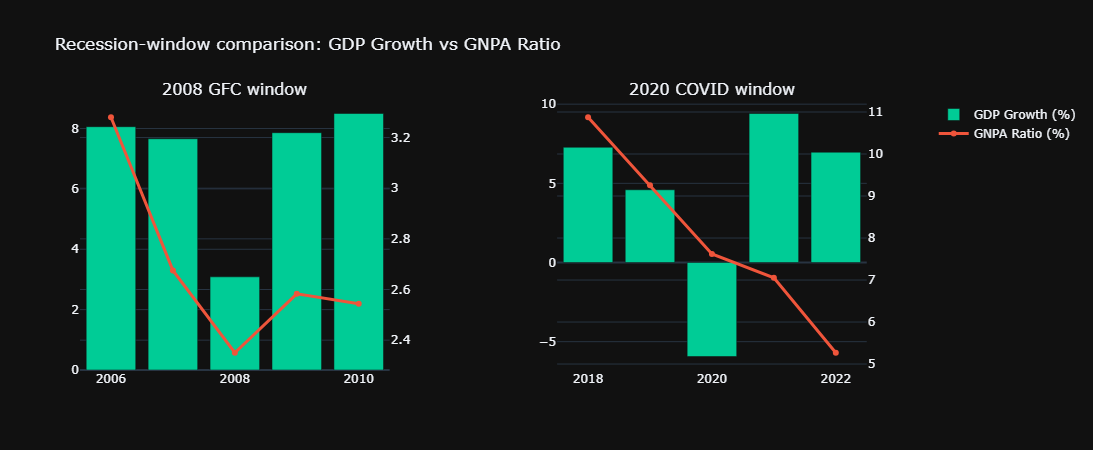

In [15]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("2008 GFC window", "2020 COVID window"),
                     specs=[[{"secondary_y": True}, {"secondary_y": True}]])

for col, yr in zip([1, 2], [2008, 2020]):
    w = window_table(yr)
    fig.add_trace(go.Bar(x=w["year"], y=w["gdp_growth"], name="GDP Growth (%)",
                          marker_color="#00CC96", showlegend=(col == 1)), row=1, col=col, secondary_y=False)
    fig.add_trace(go.Scatter(x=w["year"], y=w["gnpa_ratio"], name="GNPA Ratio (%)",
                              line=dict(color="#EF553B", width=3), mode="lines+markers",
                              showlegend=(col == 1)), row=1, col=col, secondary_y=True)

fig.update_layout(title="Recession-window comparison: GDP Growth vs GNPA Ratio", height=450)
fig.show()


## 9. Credit growth vs asset quality — did faster credit growth precede higher NPAs?

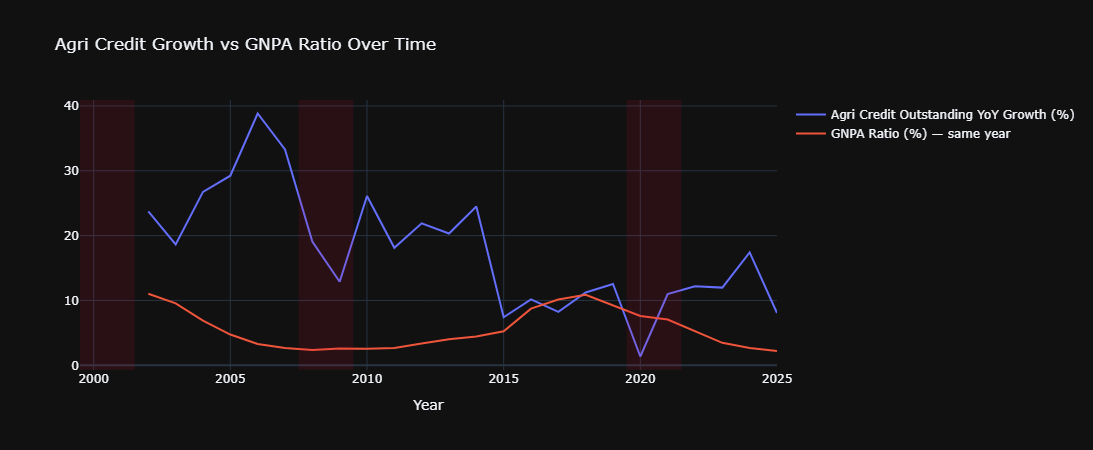

In [16]:
m = master.dropna(subset=["credit_outstanding_yoy", "gnpa_ratio"]).copy()
m_sorted = m.sort_values("year")
m_sorted["gnpa_ratio_lead2"] = m_sorted["gnpa_ratio"].shift(-2)  # NPAs often surface 2 yrs after a credit boom

fig = go.Figure()
fig.add_trace(go.Scatter(x=m_sorted["year"], y=m_sorted["credit_outstanding_yoy"],
                          name="Agri Credit Outstanding YoY Growth (%)", line=dict(color="#636EFA")))
fig.add_trace(go.Scatter(x=m_sorted["year"], y=m_sorted["gnpa_ratio"],
                          name="GNPA Ratio (%) — same year", line=dict(color="#EF553B")))
for x0, x1, label in recession_windows:
    fig.add_vrect(x0=x0, x1=x1, fillcolor="crimson", opacity=0.12, line_width=0)
fig.update_layout(title="Agri Credit Growth vs GNPA Ratio Over Time", xaxis_title="Year", height=450)
fig.show()


## 10. Conclusions template — fill in after you look at the plots above

Use this structure for your writeup. The bracketed prompts tell you exactly which cell's output to read off.

**A. What the full-period data (1970–2025) says about GDP growth around recessions**
- [Read off Section 3] Confirm the magnitude of the GDP growth dip in 2000, 2008, and 2020 relative to
  neighbouring years.

**B. What can be said about Agri credit behaviour**
- [Read off Section 4] Did Agri credit outstanding/limit keep growing through the recessions, or did YoY growth
  visibly decelerate? Note 2000 has Agri credit data (from 1998) even though it has no NPA data.

**C. What can be said about GNPA ratio behaviour — with the sector caveat repeated**
- [Read off Section 5–6] Describe the GNPA ratio trend 2002–2025: note the ratio's historical trajectory (falls
  through the 2000s credit boom, then a distinct multi-year deterioration you can date from the plot, followed
  by improvement in recent years). Cross-check the exact turning-point years against the plot rather than
  assuming they align neatly with 2008 or 2020 — RBI regulatory changes (e.g., the 2015 Asset Quality Review)
  can also drive NPA-ratio moves independent of the business cycle, and that possibility should be
  acknowledged, not ruled out.

**D. Correlation verdict**
- [Read off Section 7] State the contemporaneous and lagged Pearson/Spearman coefficients and their p-values.
  With n≈24 annual points, treat anything with p>0.05 as "suggestive, not confirmed." Explicitly say whether the
  data supports a *lagged* relationship (GDP shock → NPA rise with delay) more than a same-year one, or vice
  versa.

**E. Recession-specific verdict**
- [Read off Section 8] For 2008 and 2020 separately: did GNPA ratio rise, fall, or stay flat around the GDP
  trough? For 2000: state plainly that NPA impact cannot be assessed with this dataset.

**F. Explicit limitations to state in your final report**
1. All data is All-India; **the Gujarat 11% figure cannot be validated, contextualized only.**
2. GNPA ratio's sector-specificity (Agri vs whole book) is **unconfirmed** from the source file.
3. 2000 recession has **no NPA data** — any claim there is credit-growth-only.
4. Small-n annual correlation (≈24 points) — coefficients are indicative.
5. No causal claims possible from this data — only co-movement.
6. GNPA ratio changes can also reflect regulatory/accounting shifts (e.g., 2015 AQR), not only macro stress —
   don't attribute all ratio movement to the business cycle.

**Suggested next step if you want a stronger claim:** pull RBI's sector-wise (agriculture) GNPA data from the
Financial Stability Report / Handbook of Statistics on Indian Economy, and Gujarat SLBC data, to close gaps
1–3 above.
